In [3]:
import os                                     
import tensorflow as tf
from tensorflow.keras import layers, models          # type: ignore 
from tensorflow.keras.layers import Dropout          # type: ignore 
from tensorflow.keras.preprocessing.image import ImageDataGenerator          # type: ignore 

# For Model 3 onwards 
from tensorflow.keras.callbacks import EarlyStopping                         # type: ignore

# For Model 4
from tensorflow.keras.callbacks import ReduceLROnPlateau                     # type: ignore
from tensorflow.keras.layers import BatchNormalization                       # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint                       # type: ignore
import matplotlib.pyplot as plt

# SECTION 1 — TRAIN DATA AUGMENTATION : “image transformation machine” ----->  image processing pipeline ban rahi hai.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,

    # Model 4 onwards
    brightness_range=[0.8,1.2],
    shear_range=0.1,
    fill_mode='nearest'
    )

val_datagen = ImageDataGenerator(rescale=1./255)

# SECTION 3: TRAIN GENERATOR
train_generator = train_datagen.flow_from_directory(
    'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/02_dataset/01_train',
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)

# SECTION 4: VALIDATION GENERATOR
val_generator = val_datagen.flow_from_directory(
    'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/02_dataset/02_validate',
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)


# 3. Build CNN Model 5 :

model = models.Sequential()

#-----------------------------------------------------------------------------------------------------------------------#

# BLOCK 1 : Convolutional Layer 

model.add(layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(224,224,3)))
model.add(layers.Conv2D(32,(3,3),activation='relu',padding='same'))

#  BATCH NORMALIZATION LAYER 
model.add(BatchNormalization())

model.add(layers.MaxPooling2D((2,2)))


#-----------------------------------------------------------------------------------------------------------------------#

# BLOCK 2 : Convolutional Layer 

model.add(layers.Conv2D(64,(3,3), activation='relu',padding='same'))
model.add(layers.Conv2D(64,(3,3),activation='relu', padding='same'))

#  BATCH NORMALIZATION LAYER 
model.add(BatchNormalization())

model.add(layers.MaxPooling2D((2,2)))


#-----------------------------------------------------------------------------------------------------------------------#

# BLOCK 3 : Convolutional Layer 

model.add(layers.Conv2D(128,(3,3), activation='relu',padding='same'))
model.add(layers.Conv2D(128,(3,3),activation='relu', padding='same'))

#  BATCH NORMALIZATION LAYER 
model.add(BatchNormalization())

model.add(layers.MaxPooling2D((2,2)))

#-----------------------------------------------------------------------------------------------------------------------#

# BLOCK 4: Convolutional Layer 

model.add(layers.Conv2D(256,(3,3), activation='relu',padding='same'))
model.add(layers.Conv2D(256,(3,3),activation='relu', padding='same'))

#  BATCH NORMALIZATION LAYER 
model.add(BatchNormalization())

model.add(layers.MaxPooling2D((2,2)))

#-----------------------------------------------------------------------------------------------------------------------#

# Global Feature Aggregation
model.add(layers.GlobalAveragePooling2D())    # GlobalAveragePooling ----->reduce memorization

#-----------------------------------------------------------------------------------------------------------------------#

# Fully Connected Layers
model.add(layers.Dense(128, activation='relu'))
model.add(Dropout(0.25))                            # stronger dropout---------->better generalization
model.add(layers.Dense(64, activation='relu'))
model.add(Dropout(0.3))

#-----------------------------------------------------------------------------------------------------------------------#

# Output Layer
model.add(layers.Dense(19, activation='softmax'))


Found 24116 images belonging to 19 classes.
Found 6016 images belonging to 19 classes.


In [4]:
print(os.getcwd())

c:\Users\sanch\Documents\Git_hub\Streamlit-KrishiNetra\03_notebooks


In [5]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,216,563 (4.64 MB)

 Trainable params: 1,215,603 (4.64 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
# 4. Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])



early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '../04_models/SK_plant_model_v5_pro.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 5. TRAINING

print("\n Training started ........")
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs=16,
    callbacks=[early_stop, lr_scheduler, checkpoint]
)



 Training started ........
Epoch 1/16
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3166 - loss: 2.1770
Epoch 1: val_loss improved from None to 1.32500, saving model to ../04_models/SK_plant_model_v5_pro.keras

Epoch 1: finished saving model to ../04_models/SK_plant_model_v5_pro.keras
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 1656s 1s/step - accuracy: 0.4565 - loss: 1.7088 - val_accuracy: 0.5675 - val_loss: 1.3250 - learning_rate: 0.0010
Epoch 2/16
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6740 - loss: 0.9996
Epoch 2: val_loss improved from 1.32500 to 1.02092, saving model to ../04_models/SK_plant_model_v5_pro.keras

Epoch 2: finished saving model to ../04_models/SK_plant_model_v5_pro.keras
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 1626s 1s/step - accuracy: 0.7041 - loss: 0.9019 - val_accuracy: 0.6671 - val_loss: 1.0209 - learning_rate: 0.0010
Epoch 3/16
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 0s 997ms/step - accuracy: 0.7966 - loss: 0.6271
Epoch 3: val_loss improved from 1.02092 to 0.74894,

In [ ]:
# ==========================================================
# ACCURACY GRAPH
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    marker='o',
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# LOSS GRAPH
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

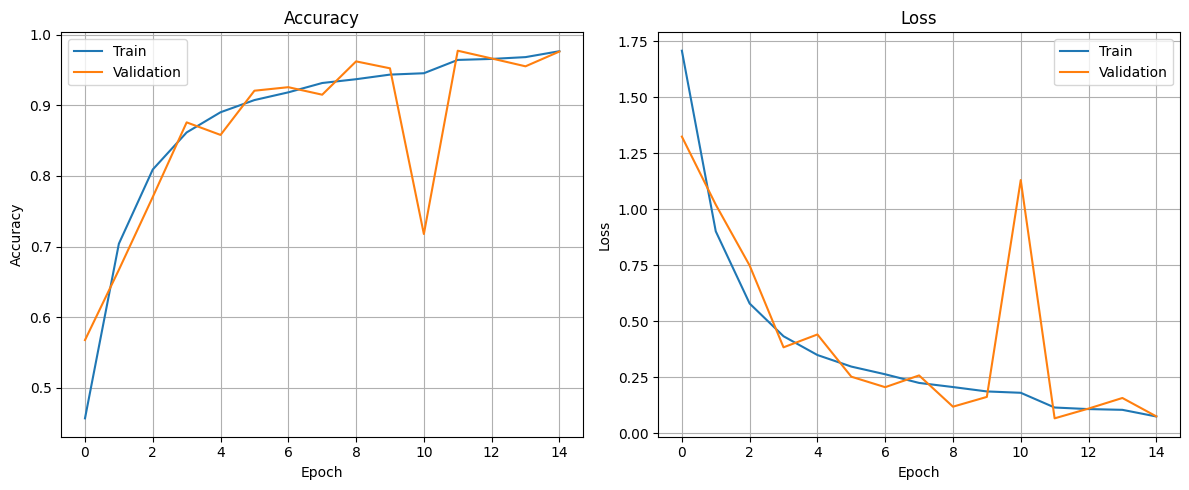

In [9]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()